In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_breast_cancer



---



In [2]:
data = load_breast_cancer(as_frame = True)
df = data.frame.copy()
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.shape

(569, 31)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 569 entries, 212 to 101
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 

In [5]:
print(f'Value counts for each class: \n{df['target'].value_counts()}')
print('\nClass proportions: ')
df['target'].value_counts(normalize=True)

Value counts for each class: 
target
1    357
0    212
Name: count, dtype: int64

Class proportions: 


,proportion
target,
1,0.627417
0,0.372583


The class proportions in the dataset: 62% cancer and 37% benign, indicating a class imbalance in the data set

In [18]:
counts = df['target'].value_counts()

fig = px.bar(
    counts,
    x=counts.index,
    y=counts.values,
    color=counts.index.astype(str),
    labels={'x': 'Class', 'y': 'Count'},
    title='Class Distribution'
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=False, # Removed the legend
    font=dict(family='Times New Roman', size=12, color='black')
)

new_names = {'0': 'benign', '1': 'malignant'}
fig.for_each_trace(lambda t: t.update(name=new_names[t.name], legendgroup=new_names[t.name]))

fig.update_xaxes(
    tickvals=[0, 1],
    ticktext=['benign', 'malignant']
)

fig.show()

In [27]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [13]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000



---



In [6]:
sub_df = df[['mean radius',	'mean perimeter',	'mean area']]

In [7]:
mean_smoothness = df['mean smoothness']
mean_smoothness.head()

,mean smoothness
0,0.11840
1,0.08474
2,0.10960
3,0.14250
4,0.10030


In [8]:
#Creating two seperate dataframes for each class
benign_df = df[df['target'] == 0]
malignant_df = df[df['target'] == 1]

In [9]:
median_rad = df['mean radius'].median()
mal_above_median = malignant_df[malignant_df['mean radius'] > median_rad]
mal_above_median.shape

(89, 31)

89 malignant cases have mean radius above the median out of 569

In [10]:
df = df.sort_values(by='mean radius', ascending=False)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
212,28.11,18.47,188.5,2499.0,0.1142,0.1516,0.3201,0.1595,0.1648,0.05525,...,18.47,188.5,2499.0,0.1142,0.1516,0.3201,0.1595,0.1648,0.05525,0
461,27.42,26.27,186.9,2501.0,0.1084,0.1988,0.3635,0.1689,0.2061,0.05623,...,31.37,251.2,4254.0,0.1357,0.4256,0.6833,0.2625,0.2641,0.07427,0
180,27.22,21.87,182.1,2250.0,0.1094,0.1914,0.2871,0.1878,0.1800,0.05770,...,32.85,220.8,3216.0,0.1472,0.4034,0.5340,0.2688,0.2856,0.08082,0
352,25.73,17.46,174.2,2010.0,0.1149,0.2363,0.3368,0.1913,0.1956,0.06121,...,23.58,229.3,3234.0,0.1530,0.5937,0.6451,0.2756,0.3690,0.08815,0
82,25.22,24.91,171.5,1878.0,0.1063,0.2665,0.3339,0.1845,0.1829,0.06782,...,33.62,211.7,2562.0,0.1573,0.6076,0.6476,0.2867,0.2355,0.10510,0


In [11]:
counts = df.groupby(['target'])['worst area'].mean().reset_index()

fig = px.bar(
    counts,
    x='target',
    y='worst area',
    color='target',
    barmode='stack',
    title='Mean worst area by class',
    labels={'target': 'Class', 'worst area': 'Mean worst area'}
)


fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Times New Roman", size=12, color="black"),
       legend=dict(
        title=dict(
            text="Class",
            side="top"
        )
 )
    )

fig.update_xaxes(showgrid=False, showline=True, linewidth=1, linecolor="black")
fig.update_yaxes(showgrid=False, showline=True, linewidth=1, linecolor="black", range=[0, None])

fig.show()

Benign class has higher mean redius than Malignant class

In [14]:
df['log10_mean_radius'] = np.log10(df['mean radius'])

fig = px.histogram(
    df,
    x='log10_mean_radius',
    color='target',
    nbins=50,
    opacity=0.55,
    title='Histogram of Log10(Mean Radius) by Class',
    barmode='overlay'
)
fig.update_layout(
    xaxis_title='Log10(Mean Radius)',
    yaxis_title='Count',
    bargap=0.05,
    template='simple_white'
)
fig.show()

In [15]:
fig = px.box(
    df,
    x='target',
    y='worst area',
    color='target',
    title='Distribution of Worst Area by Class',
    labels={'target': 'Class', 'worst area': 'Worst Area'},
    template='simple_white'
)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Times New Roman', size=12, color='black'),
    showlegend=False
)
fig.update_xaxes(showgrid=False, showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(showgrid=False, showline=True, linewidth=1, linecolor='black')
fig.show()

In [16]:
fig = px.scatter(
    df,
    x='mean radius',
    y='mean texture',
    color=df['target'].astype(str),
    title='Mean Radius vs. Mean Texture by Target',
    labels={
        'mean radius': 'Mean Radius',
        'mean texture': 'Mean Texture',
        'target': 'Target Class'
    },
    template='simple_white'
)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Times New Roman', size=12, color='black'),
    showlegend=True
)
fig.update_xaxes(showgrid=False, showline=True, linewidth=1, linecolor='black')
fig.update_yaxes(showgrid=False, showline=True, linewidth=1, linecolor='black')
fig.show()

In [17]:
num_cols =  [ 'mean radius',
              'mean texture',
              'mean perimeter',
              'mean area',
              'mean smoothness',
              'mean compactness',
              'mean concavity',
              'mean concave points',
              'mean symmetry',
              'mean fractal dimension']

corr = df[num_cols].corr()

fig = px.imshow(corr,
                text_auto=True,
                aspect="auto",
                color_continuous_scale="RdBu_r",
                title="Correlation Heatmap of Selected Numeric Features")

fig.show()


In [19]:
correlation_with_target = df.corr()['target']
print("Correlation with Target variable:\n")
print(correlation_with_target.drop('target').sort_values(ascending=False))

Correlation with Target variable:

smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
log10_mean_radius         -0.726633
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.

Features appearing down the list have the highest correaltion (negative) with the class labels in the dataset



---



In [20]:
selected_features = [
    'mean texture',
    'mean compactness',
    'mean concavity',
    'mean area',
    'mean radius',
    'mean perimeter',
    'mean concave points'
]
X = df[selected_features]
y = df['target']

In [21]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (455, 7)
X_test shape: (114, 7)
y_train shape: (455,)
y_test shape: (114,)


In [22]:

model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8947


In [24]:
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        47
           1       0.89      0.94      0.91        67

    accuracy                           0.89       114
   macro avg       0.90      0.89      0.89       114
weighted avg       0.90      0.89      0.89       114



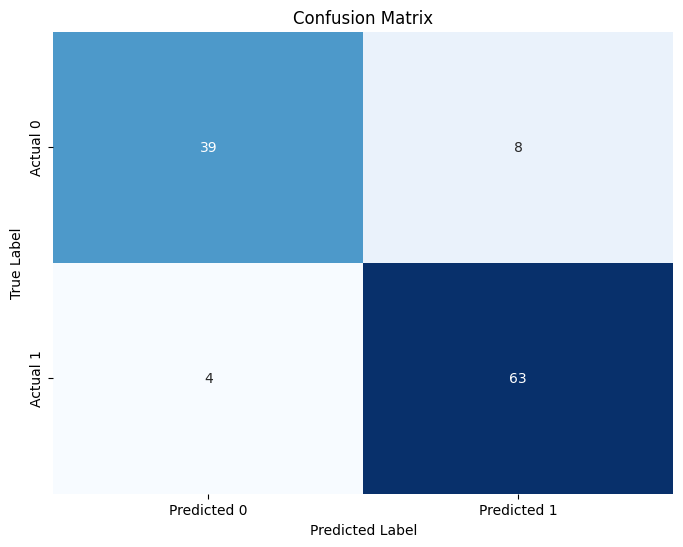

Confusion Matrix generated and displayed.


In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Confusion Matrix generated and displayed.")



---



## Summary:

The Logistic Regression model demonstrated good performance in classifying breast cancer cases, achieving an accuracy of approximately $89.5\%$ ($0.8947$) on the test set. The classification report showed strong performance for both classes:
*   For class 0 (Malignant), the precision was $0.91$, recall was $0.83$, and F1-score was $0.87$.
*   For class 1 (Benign), the precision was $0.89$, recall was $0.94$, and F1-score was $0.91$.
The confusion matrix further indicated a relatively low number of false positives and false negatives, which is important for medical diagnostic applications.


### Insights
* In medical screening, false negatives are more serious because it could lead to late intervention and cause the case to get worse. On the other hand, false positives could be detected after doing further testing and so this error should not cause a serious health issue for the case.
*   Given the medical context, further efforts could focus on reducing false negatives (misclassifying malignant as benign), possibly by adjusting the classification threshold or exploring models that prioritize recall for the malignant class.